# Transformer Language Model — DifferentialNumpy (dnp)

Testing the **real effectiveness** of the `dnp` library by training a decoder-only GPT-style language model.

| Component | What is used |
|-----------|-------------|
| Tokenizer | HuggingFace `transformers` — GPT-2 BPE (50 257 tokens) |
| Dataset | HuggingFace `datasets` — WikiText-2 |
| Embeddings | `dnp.Embedding` + `dnp.PositionalEncoding` |
| Backbone | `N × dnp.TransformerEncoderLayer` with causal mask |
| Head | `dnp.LayerNorm` + `dnp.Linear` → logits |
| Loss | `dnp.CrossEntropyLoss` |
| Optimizer | `dnp.AdamW` with `dnp.WarmupScheduler` → `dnp.CosineAnnealingLR` |
| Training loop | `dnp.Trainer` with `EarlyStopping` + `ModelCheckpoint` |

In [ ]:
# Install required packages
# Run this cell first — it installs the HuggingFace stack and (optionally) CuPy for GPU.
!pip install -q transformers datasets
# Uncomment if on a CUDA 12.x GPU (Colab A100 / T4):
# !pip install -q cupy-cuda12x

import subprocess, sys

# Clone the v3 branch and install the package in editable mode
result = subprocess.run(
    ["git", "clone", "--branch", "v3", "--depth", "1",
     "https://github.com/Seydifa/AutoDiff-Numpy.git", "DifferentialNumpy"],
    capture_output=True, text=True
)
if result.returncode != 0 and "already exists" not in result.stderr:
    print(result.stderr)
else:
    if "already exists" in result.stderr:
        # Pull latest fixes from v3 branch
        subprocess.run(
            ["git", "-C", "DifferentialNumpy", "pull", "--rebase", "origin", "v3"],
            capture_output=True
        )
    print("Repo ready.")

# Make the package importable
if "DifferentialNumpy" not in sys.path:
    sys.path.insert(0, "DifferentialNumpy")
print("sys.path updated.")

Repo ready.
sys.path updated.


In [2]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass

import dnp
from dnp.core.backend import as_numpy
from dnp.core.session import session

# HuggingFace
from transformers import AutoTokenizer
from datasets import load_dataset

# GPU detection
try:
    import cupy as cp
    DEVICE = "cuda"
    print("CuPy detected — using GPU")
except ImportError:
    DEVICE = "cpu"
    print("CuPy not available — using CPU")

dnp.set_device(DEVICE)
print(f"dnp device: {DEVICE}")

CuPy detected — using GPU
dnp device: cuda


## 1 — Configuration

A HuggingFace-style `@dataclass` gathers every hyper-parameter in one place.

| Group | Key params |
|-------|------------|
| **Model** | `d_model`, `num_heads`, `d_ff`, `num_layers` |
| **Context** | `block_size` — sequence length (tokens) |
| **Training** | `lr`, `weight_decay`, `epochs`, `warmup_epochs` |
| **Data** | `max_train_seqs`, `max_val_seqs` — cap sequences for speed |

Adjust `max_train_seqs` / `max_val_seqs` to control run time vs. data coverage.

In [3]:
@dataclass
class Config:
    # ── Tokenizer ─────────────────────────────────────────────────────────
    tokenizer_id: str  = "gpt2"          # HuggingFace tokenizer/model id
    vocab_size:   int  = 50_257          # GPT-2 vocabulary size

    # ── Model ─────────────────────────────────────────────────────────────
    d_model:    int   = 128              # embedding / hidden dimension
    num_heads:  int   = 4                # attention heads (d_model % num_heads == 0)
    d_ff:       int   = 512              # FFN inner dimension (4 × d_model)
    num_layers: int   = 4                # number of TransformerEncoderLayer blocks
    dropout_p:  float = 0.1             # dropout probability

    # ── Sequence ──────────────────────────────────────────────────────────
    block_size: int   = 64              # context window (tokens)

    # ── Training ──────────────────────────────────────────────────────────
    lr:             float = 3e-4        # peak learning rate
    lr_min:         float = 1e-6        # cosine annealing floor
    weight_decay:   float = 0.01        # AdamW weight decay
    epochs:         int   = 10          # total training epochs
    warmup_epochs:  int   = 1           # linear LR warm-up epochs
    batch_size:     int   = 32          # mini-batch size

    # ── Data ──────────────────────────────────────────────────────────────
    dataset_name:   str   = "wikitext"
    dataset_config: str   = "wikitext-2-raw-v1"
    max_train_seqs: int   = 5_000       # cap training sequences (set None for all)
    max_val_seqs:   int   = 500         # cap validation sequences

    # ── Checkpointing ─────────────────────────────────────────────────────
    ckpt_path: str = "best_gpt_decoder.npz"


cfg = Config()
print(f"Config ready — d_model={cfg.d_model}, heads={cfg.num_heads}, "
      f"layers={cfg.num_layers}, block_size={cfg.block_size}, "
      f"vocab={cfg.vocab_size:,}, device={DEVICE}")

Config ready — d_model=128, heads=4, layers=4, block_size=64, vocab=50,257, device=cuda


## 2 — Dataset & Tokenizer

**WikiText-2** is a standard language-model benchmark — clean Wikipedia prose, ~2 M tokens.  
We use the **GPT-2 BPE tokeniser** from HuggingFace `transformers` so the vocabulary is identical
to the pre-trained GPT-2 (50 257 tokens, byte-level BPE).

Steps:
1. Load train / validation splits with `datasets.load_dataset`.
2. Tokenise all text in one shot with `tokenizer.encode`.
3. Chunk the resulting token stream into non-overlapping `block_size + 1` windows.

In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────
print("Loading WikiText-2 ...")
raw = load_dataset(cfg.dataset_name, cfg.dataset_config)

# Join all non-empty lines into a single string per split
def join_texts(split):
    return "\n".join(t for t in raw[split]["text"] if t.strip())

train_text = join_texts("train")
val_text   = join_texts("validation")
test_text  = join_texts("test")

print(f"  train  chars: {len(train_text):,}")
print(f"  val    chars: {len(val_text):,}")
print(f"  test   chars: {len(test_text):,}")

# ── Load GPT-2 tokenizer ───────────────────────────────────────────────────
print("\nLoading GPT-2 tokeniser ...")
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_id)
tokenizer.pad_token = tokenizer.eos_token

# ── Tokenise ───────────────────────────────────────────────────────────────
print("Tokenising ...")
t0 = time.time()
train_ids = tokenizer.encode(train_text)
val_ids   = tokenizer.encode(val_text)
test_ids  = tokenizer.encode(test_text)
elapsed   = time.time() - t0

print(f"  train  tokens: {len(train_ids):,}")
print(f"  val    tokens: {len(val_ids):,}")
print(f"  test   tokens: {len(test_ids):,}")
print(f"  tokenised in {elapsed:.1f}s")
print(f"\nSample (first 20 tokens): {tokenizer.decode(train_ids[:20])!r}")

Loading WikiText-2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


  train  chars: 10,916,756
  val    chars: 1,144,610
  test   chars: 1,288,512

Loading GPT-2 tokeniser ...
Tokenising ...


Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


  train  tokens: 2,391,884
  val    tokens: 247,289
  test   tokens: 283,287
  tokenised in 11.6s

Sample (first 20 tokens): ' = Valkyria Chronicles III = \n\n Senjō no Valkyria 3 : Unrecorded'


In [5]:
def make_xy(ids, block_size, max_seqs=None):
    """Chunk a flat token list into (input, target) sequence pairs.

    Each window of `block_size + 1` consecutive tokens produces:
      x[i] = tokens[i : i + block_size]       <- input context
      y[i] = tokens[i + 1 : i + 1 + block_size]  <- next-token targets
    """
    L    = block_size + 1
    seqs = [ids[i : i + L] for i in range(0, len(ids) - L + 1, L)]
    seqs = [s for s in seqs if len(s) == L]
    if max_seqs is not None:
        seqs = seqs[:max_seqs]
    arr = np.array(seqs, dtype=np.int32)
    return arr[:, :-1], arr[:, 1:]


x_train, y_train = make_xy(train_ids, cfg.block_size, max_seqs=cfg.max_train_seqs)
x_val,   y_val   = make_xy(val_ids,   cfg.block_size, max_seqs=cfg.max_val_seqs)
x_test,  y_test  = make_xy(test_ids,  cfg.block_size, max_seqs=cfg.max_val_seqs)

print(f"Training sequences : {x_train.shape}  ->  {y_train.shape}")
print(f"Validation seqs    : {x_val.shape}")
print(f"Test sequences     : {x_test.shape}")
print(f"\nToken range in x_train: [{x_train.min()}, {x_train.max()}]  (vocab_size={cfg.vocab_size})")

# Quick sanity check
idx = 0
print(f"\nSample x[0]: {tokenizer.decode(x_train[idx].tolist())[:80]!r}")
print(f"Sample y[0]: {tokenizer.decode(y_train[idx].tolist())[:80]!r}")

Training sequences : (5000, 64)  ->  (5000, 64)
Validation seqs    : (500, 64)
Test sequences     : (500, 64)

Token range in x_train: [11, 50251]  (vocab_size=50257)

Sample x[0]: ' = Valkyria Chronicles III = \n\n Senjō no Valkyria 3 : Unrecorded Chronicles ( Ja'
Sample y[0]: ' Valkyria Chronicles III = \n\n Senjō no Valkyria 3 : Unrecorded Chronicles ( Japa'


## 3 — Model Architecture — `GPTDecoder`

A **decoder-only** (GPT-style) language model built exclusively from `dnp` native layers.

```
Input (B, T)  ->  dnp.Embedding  ->  dnp.PositionalEncoding
             ->  N x dnp.TransformerEncoderLayer  (with causal mask)
             ->  dnp.LayerNorm
             ->  dnp.Linear  ->  logits (B, T, vocab_size)
```

**Why `TransformerEncoderLayer` for a decoder?**  
A decoder-only LM is an encoder with a **causal (upper-triangular) attention mask** that prevents
each position from attending to future tokens.  The `TransformerDecoderLayer` in dnp is the full
*encoder-decoder* cross-attention block; it requires an encoder memory tensor and is therefore
reserved for seq2seq models.

The causal mask has shape `(T, T)` with `True` where future tokens should be masked to `-inf` before softmax.

In [6]:
class GPTDecoder(dnp.Module):
    """Decoder-only transformer language model using dnp native layers.

    Architecture
    ------------
    token_emb : dnp.Embedding           (vocab_size, d_model)
    pos_enc   : dnp.PositionalEncoding   sinusoidal, non-trainable
    enc_0 ... enc_{N-1} : dnp.TransformerEncoderLayer  with causal mask
    norm      : dnp.LayerNorm            final layer normalisation
    lm_head   : dnp.Linear               (d_model -> vocab_size) projection
    """

    def __init__(self, cfg):
        super().__init__()
        self.block_size = cfg.block_size
        self.num_layers = cfg.num_layers

        # Token embedding table
        self.token_emb = dnp.Embedding(cfg.vocab_size, cfg.d_model)

        # Sinusoidal positional encoding (non-trainable buffer)
        self.pos_enc = dnp.PositionalEncoding(
            cfg.d_model, max_len=cfg.block_size + 1, dropout_p=cfg.dropout_p
        )

        # Stack of TransformerEncoderLayer blocks
        # Registered via setattr so Module discovers them in _modules
        for i in range(cfg.num_layers):
            setattr(
                self, f"enc_{i}",
                dnp.TransformerEncoderLayer(
                    cfg.d_model, cfg.num_heads, cfg.d_ff,
                    dropout_p=cfg.dropout_p, activation="gelu",
                )
            )

        # Final layer norm (pre-head)
        self.norm = dnp.LayerNorm(cfg.d_model)

        # Vocabulary projection — no bias (standard GPT practice)
        self.lm_head = dnp.Linear(cfg.d_model, cfg.vocab_size, bias=False)

    def _causal_mask(self, T):
        """Boolean (T, T) causal mask: True at positions that attend to future tokens."""
        mask = np.triu(np.ones((T, T), dtype=bool), k=1)
        if next(self.parameters()).device == "cuda":
            import cupy as cp
            mask = cp.asarray(mask)
        return mask

    def forward(self, x):
        """Forward pass.

        Parameters
        ----------
        x : dnp.Tensor | np.ndarray  shape (B, T)  integer token ids
        """
        xdata = x.data if isinstance(x, dnp.Tensor) else np.asarray(x)
        T = int(xdata.shape[1])

        # 1. Token embeddings  (B, T) -> (B, T, d_model)
        h = self.token_emb(x)

        # 2. Add sinusoidal positional encoding
        h = self.pos_enc(h)

        # 3. Build causal attention mask (True = mask this position)
        causal_mask = self._causal_mask(T)

        # 4. Apply N decoder blocks (TransformerEncoderLayer + causal mask)
        for i in range(self.num_layers):
            h = getattr(self, f"enc_{i}")(h, mask=causal_mask)

        # 5. Final layer norm + vocabulary projection
        h = self.norm(h)
        return self.lm_head(h)    # (B, T, vocab_size)


print("GPTDecoder class defined.")

GPTDecoder class defined.


In [7]:
np.random.seed(42)

# Instantiate — weights are allocated on DEVICE
model = GPTDecoder(cfg)

n_params = model.num_parameters()
print(f"GPTDecoder  |  {n_params:,} trainable parameters")
print(f"  token_emb : {cfg.vocab_size * cfg.d_model:,} params  ({cfg.vocab_size} x {cfg.d_model})")
print(f"  lm_head   : {cfg.d_model * cfg.vocab_size:,} params  ({cfg.d_model} x {cfg.vocab_size})")
print(f"  {cfg.num_layers} x TransformerEncoderLayer  "
      f"(d_model={cfg.d_model}, heads={cfg.num_heads}, d_ff={cfg.d_ff})")

# Quick shape smoke-test (no grad tracking)
dummy_x = np.random.randint(0, cfg.vocab_size, size=(2, cfg.block_size), dtype=np.int32)
with session.no_grad():
    dummy_out = model(dnp.Tensor(dummy_x))
    out_shape = dummy_out.data.shape
session.reset()

assert out_shape == (2, cfg.block_size, cfg.vocab_size), f"Unexpected shape: {out_shape}"
print(f"\nSmoke test  x:{dummy_x.shape} -> logits:{out_shape}  OK")

GPTDecoder  |  13,657,088 trainable parameters
  token_emb : 6,432,896 params  (50257 x 128)
  lm_head   : 6,432,896 params  (128 x 50257)
  4 x TransformerEncoderLayer  (d_model=128, heads=4, d_ff=512)

Smoke test  x:(2, 64) -> logits:(2, 64, 50257)  OK


## 4 — Training

The `dnp.Trainer` handles the full training lifecycle.

| Component | What is used |
|-----------|-------------|
| Optimiser | `dnp.AdamW` — decoupled weight decay |
| Scheduler | `dnp.WarmupScheduler` (linear warmup) → `dnp.CosineAnnealingLR` |
| Loss | `dnp.CrossEntropyLoss` — handles `(B, T, V)` logits natively |
| Callbacks | `dnp.EarlyStopping(patience=3)` + `dnp.ModelCheckpoint` |

The trainer logs `loss` and `val_loss` each epoch.
The best model weights are saved to `cfg.ckpt_path`.

In [8]:
# ── Optimizer ──────────────────────────────────────────────────────────────
optimizer = dnp.AdamW(
    list(model.parameters()),
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
)

# ── LR Scheduler: linear warmup -> cosine annealing ────────────────────────
cosine_lr = dnp.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=cfg.lr_min)
scheduler = dnp.WarmupScheduler(
    optimizer, warmup_epochs=cfg.warmup_epochs, after_scheduler=cosine_lr
)
print(f"Initial LR: {optimizer.lr:.2e}")

# ── Loss ────────────────────────────────────────────────────────────────────
# CrossEntropyLoss auto-flattens (B, T, V) logits -> (B*T, V) before computing loss
loss_fn = dnp.CrossEntropyLoss()

# ── Callbacks ───────────────────────────────────────────────────────────────
callbacks = [
    dnp.EarlyStopping(monitor="val_loss", patience=3, verbose=True),
    dnp.ModelCheckpoint(
        filepath=cfg.ckpt_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=True,
    ),
]

# ── Trainer ─────────────────────────────────────────────────────────────────
trainer = dnp.Trainer(
    model,
    optimizer,
    loss_fn,
    scheduler=scheduler,
    callbacks=callbacks,
    verbose=True,
)
print("Trainer ready.")

Initial LR: 3.00e-04
Trainer ready.


In [9]:
print(f"Training on {DEVICE.upper()} — {x_train.shape[0]:,} sequences "
      f"x {cfg.block_size} tokens/seq, batch_size={cfg.batch_size}")
print(f"  Batches/epoch : {x_train.shape[0] // cfg.batch_size}")
print(f"  Epochs        : {cfg.epochs}")
print()

t0 = time.time()

history = trainer.fit(
    x_train, y_train,
    epochs       = cfg.epochs,
    batch_size   = cfg.batch_size,
    validation_data = (x_val, y_val),
)

elapsed = time.time() - t0
print(f"\nTotal training time : {elapsed:.1f}s")
print(f"Final     train loss: {history.history['loss'][-1]:.4f}")
if "val_loss" in history.history:
    print(f"Final       val loss: {history.history['val_loss'][-1]:.4f}")
    best_val = min(history.history["val_loss"])
    print(f"Best        val loss: {best_val:.4f}  (perplexity approx {math.exp(best_val):.1f})")

Training on CUDA — 5,000 sequences x 64 tokens/seq, batch_size=32
  Batches/epoch : 156
  Epochs        : 10



AttributeError: 'list' object has no attribute 'argsort'

## 5 — Evaluation

**Metrics**:
- **Cross-entropy loss** — average negative log-likelihood per token.
- **Perplexity** = exp(CE loss) — the standard language model quality metric.  
  Lower is better. A model that assigns equal probability to all 50 k tokens would have perplexity 50 257.

We evaluate on the held-out **test** set after reloading the best checkpoint saved during training.

NameError: name 'history' is not defined

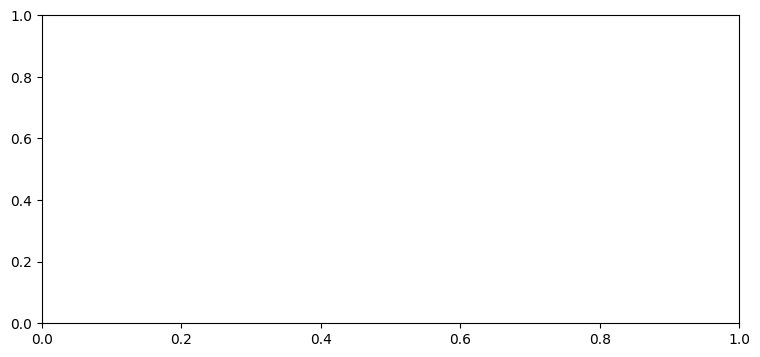

In [10]:
# ── Training curves ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
epochs_ran = range(1, len(history.history["loss"]) + 1)
ax.plot(epochs_ran, history.history["loss"], label="Train loss", color="steelblue")
if "val_loss" in history.history:
    ax.plot(epochs_ran, history.history["val_loss"], label="Val loss",
            color="darkorange", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("GPTDecoder — WikiText-2 Language Modelling")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("gpt_training_curves.png", dpi=120)
plt.show()
print("Saved -> gpt_training_curves.png")

In [ ]:
import os

# ── Reload best checkpoint ─────────────────────────────────────────────────
def load_checkpoint(model, path):
    """Restore model parameters from a .npz checkpoint (device-aware)."""
    ckpt = np.load(path, allow_pickle=False)
    missing = []
    for name, p in model.named_parameters():
        if name in ckpt:
            arr = ckpt[name].astype(np.float32)
            if p.device == "cuda":
                import cupy as cp
                p.data = cp.asarray(arr)
            else:
                p.data = arr
        else:
            missing.append(name)
    if missing:
        print(f"Missing keys: {missing}")
    else:
        print(f"Checkpoint loaded <- {path}  ({len(list(ckpt.keys()))} tensors)")


if os.path.exists(cfg.ckpt_path):
    load_checkpoint(model, cfg.ckpt_path)
else:
    print("No checkpoint found — evaluating current weights.")

# ── Test-set evaluation ────────────────────────────────────────────────────
test_loss = trainer.evaluate(x_test, y_test, batch_size=cfg.batch_size)
test_ppl  = math.exp(test_loss)

print(f"\nTest cross-entropy : {test_loss:.4f}")
print(f"Test perplexity    : {test_ppl:.1f}  (random baseline = {cfg.vocab_size:,})")

# ── Perplexity bar chart ───────────────────────────────────────────────────
labels = ["Random\nbaseline", "Train\n(final)", "Val\n(best)", "Test"]
ppls   = [
    cfg.vocab_size,
    math.exp(history.history["loss"][-1]),
    math.exp(min(history.history.get("val_loss", [history.history["loss"][-1]]))),
    test_ppl,
]
colors = ["#d9534f", "#5bc0de", "#5cb85c", "#f0ad4e"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, ppls, color=colors, edgecolor="white", linewidth=1.2)
ax.set_yscale("log")
ax.set_ylabel("Perplexity  (log scale, lower is better)")
ax.set_title("Perplexity Comparison — GPTDecoder on WikiText-2")
for bar, v in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.1,
            f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("gpt_perplexity.png", dpi=120)
plt.show()
print("Saved -> gpt_perplexity.png")

## 6 — Text Generation

The model produces text **autoregressively**: at each step it predicts the next token given all previous ones.

**Sampling strategies**:

| Strategy | temperature | top_k | Effect |
|----------|------------|-------|--------|
| Greedy | 0.1 | 1 | Deterministic, repetitive |
| Balanced | 0.8 | 40 | Good variety, coherent |
| Creative | 1.2 | 0 | High entropy, unexpected |

Inference runs under `session.no_grad()` — the computation graph is not built, reducing memory overhead.

In [ ]:
def generate(
    model,
    tokenizer,
    prompt,
    max_new_tokens=80,
    temperature=0.8,
    top_k=40,
):
    """Autoregressive next-token generation.

    Parameters
    ----------
    model          : GPTDecoder           trained dnp model
    tokenizer      : HF AutoTokenizer     for encoding/decoding
    prompt         : str                  text prompt to continue
    max_new_tokens : int                  number of new tokens to generate
    temperature    : float                logit temperature (0 -> greedy, > 1 -> creative)
    top_k          : int                  keep only top-k tokens before sampling (0 = all)
    """
    model.eval()
    ids     = tokenizer.encode(prompt, add_special_tokens=False)
    context = np.array([ids[-cfg.block_size:]], dtype=np.int32)   # (1, T)
    n_prompt_kept = len(context[0])

    for _ in range(max_new_tokens):
        with session.no_grad():
            logits_t = model(dnp.Tensor(context))   # (1, T, V)
        session.reset()

        # Extract last-position logits and move to CPU numpy
        logits_np = as_numpy(logits_t.data)[0, -1].astype(np.float64)  # (V,)

        # Temperature scaling
        logits_np /= max(temperature, 1e-8)

        # Top-k filtering
        if top_k > 0:
            kth = np.sort(logits_np)[-min(top_k, len(logits_np))]
            logits_np[logits_np < kth] = -np.inf

        # Stable softmax -> sample
        logits_np -= logits_np.max()
        probs   = np.exp(logits_np)
        probs  /= probs.sum()
        next_id = int(np.random.choice(len(probs), p=probs))

        context = np.concatenate([context, [[next_id]]], axis=1)
        # Slide context window
        if context.shape[1] > cfg.block_size:
            context = context[:, -cfg.block_size:]

    model.train()
    return tokenizer.decode(context[0, n_prompt_kept:].tolist(), skip_special_tokens=True)


# ── Demo generation ───────────────────────────────────────────────────────
prompts = [
    "The history of artificial intelligence",
    "In the field of mathematics",
]
strategies = [
    dict(temperature=0.1, top_k=1,  label="Greedy (temp=0.1, top_k=1)"),
    dict(temperature=0.8, top_k=40, label="Balanced (temp=0.8, top_k=40)"),
    dict(temperature=1.2, top_k=0,  label="Creative (temp=1.2, top_k=0)"),
]

np.random.seed(0)
for prompt in prompts:
    print(f"\n{'---' * 20}")
    print(f"PROMPT: {prompt!r}")
    for strat in strategies:
        continuation = generate(
            model, tokenizer, prompt,
            max_new_tokens=50,
            temperature=strat["temperature"],
            top_k=strat["top_k"],
        )
        print(f"\n  [{strat['label']}]")
        print(f"  {continuation}")